# RISIKO PENYAKIT DIABETES

#### Anggota Kelompok :
1. Alicia Mazza (103012330089)
2. Muhammad Akbar Putra Pahlawan (103012330227)
3. Nabilah Desky Putri (103012300343)

### A. Data Medis Pasien
Dataset yang digunakan dalam penelitian ini merupakan data medis pasien yang bertujuan untuk memprediksi apakah seorang pasien menderita diabetes atau tidak. Dataset ini terdiri dari beberapa variabel. Nilai pada kolom Outcome menunjukkan apakah pasien positif diabetes (1) atau negatif (0). Dalam analisis ini, prediksi akan difokuskan hanya pada dua parameter, yaitu usia dan kadar glukosa, untuk disederhanakan ke dalam model sistem inferensi fuzzy metode Mamdani dan Sugeno. 

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

data = pd.read_csv("data_pasien_diabetes.csv", sep=";")
print("Jumlah baris : ",len(data))
data.tail()

Jumlah baris :  768


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


In [4]:
# Simpan info sebelum pembersihan
jumlah_awal = len(data)
age_zero_awal = (data['Age'] == 0).sum()
glucose_zero_awal = (data['Glucose'] == 0).sum()

# Bersihkan data (mengubah DataFrame asli)
data = data[(data['Age'] != 0) & (data['Glucose'] != 0)]

# Cek jumlah baris aktual
print("Jumlah baris setelah dibersihkan:", len(data))

# Reset index agar mulai dari 0
data = data.reset_index(drop=True)

data.tail()

Jumlah baris setelah dibersihkan: 763


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
758,10,101,76,48,180,32.9,0.171,63,0
759,2,122,70,27,0,36.8,0.340,27,0
760,5,121,72,23,112,26.2,0.245,30,0
761,1,126,60,0,0,30.1,0.349,47,1
762,1,93,70,31,0,30.4,0.315,23,0


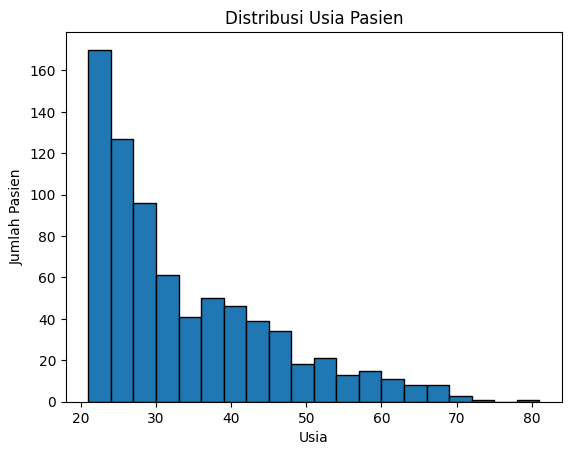

In [5]:
plt.hist(data['Age'], bins=20, edgecolor='black')
plt.title(f'Distribusi Usia Pasien')
plt.xlabel('Usia')
plt.ylabel('Jumlah Pasien')
plt.show()

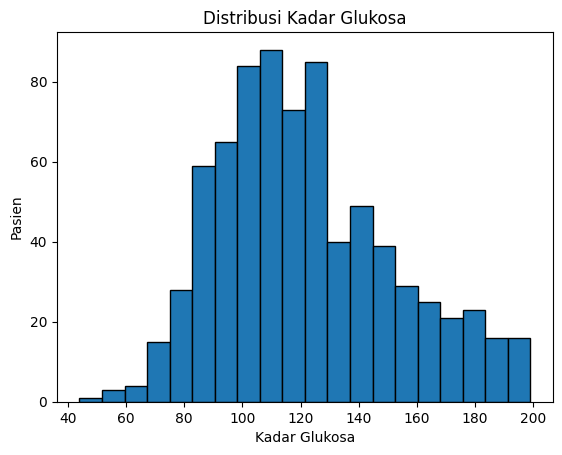

In [6]:
plt.hist(data['Glucose'], bins=20, edgecolor='black')
plt.title('Distribusi Kadar Glukosa')
plt.xlabel('Kadar Glukosa')
plt.ylabel('Pasien')
plt.show()

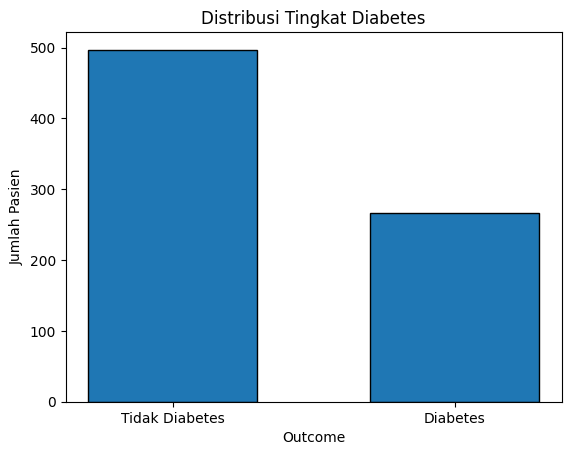

In [7]:
plt.hist(data['Outcome'], bins=[-0.5, 0.5, 1.5], edgecolor='black', rwidth=0.6)
plt.xticks([0, 1], ['Tidak Diabetes', 'Diabetes'])
plt.title('Distribusi Tingkat Diabetes')
plt.xlabel('Outcome')
plt.ylabel('Jumlah Pasien')
plt.show()

### B. Proses Fuzzifikasi & Defuzzifikasi

In [8]:
# Fungsi segitiga (triangular)
def trimf(x, a, b, c):
    return np.maximum(np.minimum((x - a)/(b - a + 1e-6), (c - x)/(c - b + 1e-6)), 0)

# Fungsi trapesium (trapezoidal)
def trapmf(x, a, b, c, d):
    return np.maximum(np.minimum(np.minimum((x - a)/(b - a + 1e-6), 1), (d - x)/(d - c + 1e-6)), 0)

def fuzzify_usia(u):
    return {
        'muda': trapmf(u, 0, 0, 20, 35),
        'paruh_baya': trimf(u, 30, 45, 63),
        'tua': trapmf(u, 55, 70, 100, 100)
    }

def fuzzify_glukosa(g):
    return {
        'rendah': trapmf(g, 0, 0, 80, 100),
        'sedang': trimf(g, 90, 120, 150),
        'tinggi': trapmf(g, 140, 160, 200, 200)
    }
def inference_mamdani(usia_deg, glukosa_deg):
    return {
        'aman': max(
            # Kondisi aman utama
            min(usia_deg['muda'], glukosa_deg['rendah']),
            min(usia_deg['muda'], glukosa_deg['sedang']),
            min(usia_deg['paruh_baya'], glukosa_deg['rendah']),
            min(usia_deg['tua'], glukosa_deg['rendah']),  
            
        ),
        'berisiko': max(
            # Kondisi berisiko utama
            min(usia_deg['tua'], glukosa_deg['tinggi']),
            min(usia_deg['tua'], glukosa_deg['sedang']),
            min(usia_deg['paruh_baya'], glukosa_deg['tinggi']),
            min(usia_deg['muda'], glukosa_deg['tinggi']),
            min(usia_deg['paruh_baya'], glukosa_deg['sedang'])
        )
    }

def defuzzify_mamdani(output_fuzzy):
    # Titik pusat disesuaikan
    aman_center = 25  
    berisiko_center = 75  
    
    aman = output_fuzzy['aman'] * aman_center
    berisiko = output_fuzzy['berisiko'] * berisiko_center

    total = output_fuzzy['aman'] + output_fuzzy['berisiko']

    if total != 0:
        return (aman + berisiko) / total
    else:
        return 50  # Ambang batas

def fuzzy_diabetes_mamdani(usia, glukosa):
    usia_fuzzy = fuzzify_usia(usia)
    glukosa_fuzzy = fuzzify_glukosa(glukosa)
    output_fuzzy = inference_mamdani(usia_fuzzy, glukosa_fuzzy)
    return defuzzify_mamdani(output_fuzzy)


# Inferensi Sugeno: rule base dengan output konstanta
def inference_sugeno_linear(usia, glukosa, usia_deg, glukosa_deg):
    rules = []

    # Aturan Aman (z < 50)
    # Aturan 1: muda & rendah → aman 
    alpha1 = min(usia_deg['muda'], glukosa_deg['rendah'])
    z1 = 25  # Nilai rendah menunjukkan aman
    rules.append((alpha1, z1))

    # Aturan 2: paruh_baya & rendah → aman
    alpha2 = min(usia_deg['paruh_baya'], glukosa_deg['rendah'])
    z2 = 30
    rules.append((alpha2, z2))

    # Aturan 3: tua & rendah → aman (dengan pertimbangan usia)
    alpha3 = min(usia_deg['tua'], glukosa_deg['rendah'])
    z3 = 40  # Lebih tinggi karena usia tua
    rules.append((alpha3, z3))

    # Aturan 4: muda & sedang → aman (dengan pertimbangan)
    alpha4 = min(usia_deg['muda'], glukosa_deg['sedang'])
    z4 = 45  # Mendekati ambang
    rules.append((alpha4, z4))

    # Aturan Berisiko (z >= 50)
    # Aturan 5: paruh_baya & sedang → risiko
    alpha5 = min(usia_deg['paruh_baya'], glukosa_deg['sedang'])
    z5 = 55
    rules.append((alpha5, z5))

    # Aturan 6: tua & sedang → risiko
    alpha6 = min(usia_deg['tua'], glukosa_deg['sedang'])
    z6 = 65  # Lebih berisiko karena usia
    rules.append((alpha6, z6))

    # Aturan 7: muda & tinggi → risiko
    alpha7 = min(usia_deg['muda'], glukosa_deg['tinggi'])
    z7 = 60
    rules.append((alpha7, z7))

    # Aturan 8: paruh_baya & tinggi → risiko
    alpha8 = min(usia_deg['paruh_baya'], glukosa_deg['tinggi'])
    z8 = 70
    rules.append((alpha8, z8))

    # Aturan 9: tua & tinggi → risiko tinggi
    alpha9 = min(usia_deg['tua'], glukosa_deg['tinggi'])
    z9 = 80
    rules.append((alpha9, z9))

    return rules

def defuzzify_sugeno_linear(rules):
    numerator = sum(alpha * z for alpha, z in rules)
    denominator = sum(alpha for alpha, _ in rules)

    if denominator != 0:
        return numerator / denominator
    else:
        return 50  # default

# Fungsi utama fuzzy Sugeno
def fuzzy_diabetes_sugeno_linear(usia, glukosa):
    usia_fuzzy = fuzzify_usia(usia)
    glukosa_fuzzy = fuzzify_glukosa(glukosa)
    rules = inference_sugeno_linear(usia, glukosa, usia_fuzzy, glukosa_fuzzy)
    return defuzzify_sugeno_linear(rules)

# Interpretasi hasil
def interpretasi_nilai(n):
    if n < 50:
        return "Aman"
    else:
        return "Berisiko"

### C. Visualisasi Keanggotaan Usia & Kadar Glukosa
Pada proses ini didefinisikan fungsi keanggotaan untuk setiap variabel input. Dalam penelitian ini, dua variabel yang digunakan adalah usia dan kadar glukosa darah. Masing-masing variabel dibagi ke dalam tiga kategori fuzzy menggunakan fungsi keanggotaan berbentuk segitiga dan trapesium. Variabel usia dikategorikan menjadi Muda, Paruh Baya, dan Tua, sedangkan variabel glukosa diklasifikasikan menjadi Rendah, Sedang, dan Tinggi. Gambar berikut menunjukkan visualisasi dari fungsi keanggotaan yang digunakan dalam proses fuzzifikasi.

Masukkan sampel usia:  78


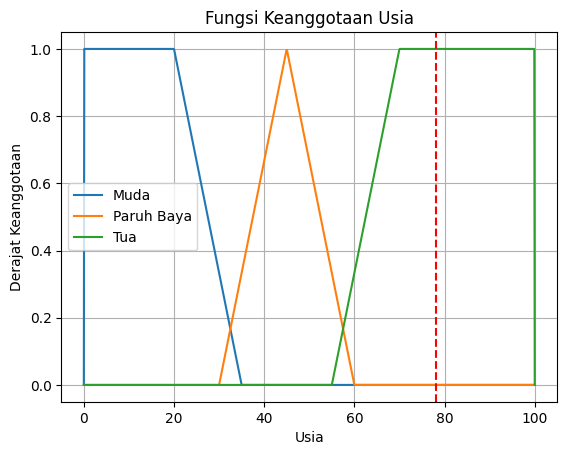

Masukkan sampel kadar glukosa:  108


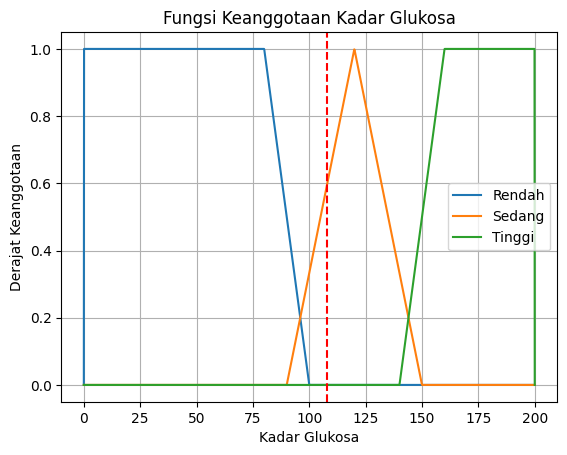

In [10]:
# Variabel Input Usia
usia_sampel = int(input("Masukkan sampel usia: "))

x_usia = np.linspace(0, 100, 1000)

muda = trapmf(x_usia, 0, 0, 20, 35)
paruh_baya = trimf(x_usia, 30, 45, 60)
tua = trapmf(x_usia, 55, 70, 100, 100)

plt.figure()
plt.plot(x_usia, muda, label='Muda')
plt.plot(x_usia, paruh_baya, label='Paruh Baya')
plt.plot(x_usia, tua, label='Tua')

# Tambahkan garis vertikal dan anotasi
plt.axvline(usia_sampel, color='red', linestyle='--')
plt.title("Fungsi Keanggotaan Usia")
plt.xlabel("Usia")
plt.ylabel("Derajat Keanggotaan")
plt.legend()
plt.grid(True)
plt.show()

# Variabel Input Kadar Glukosa
glukosa_sampel = int(input("Masukkan sampel kadar glukosa: "))

x_glukosa = np.linspace(0, 200, 2000)

rendah = trapmf(x_glukosa, 0, 0, 80, 100)
sedang = trimf(x_glukosa, 90, 120, 150)
tinggi = trapmf(x_glukosa, 140, 160, 200, 200)

plt.figure()
plt.plot(x_glukosa, rendah, label='Rendah')
plt.plot(x_glukosa, sedang, label='Sedang')
plt.plot(x_glukosa, tinggi, label='Tinggi')

# Tambahkan garis vertikal dan anotasi
plt.axvline(glukosa_sampel, color='red', linestyle='--')

plt.title("Fungsi Keanggotaan Kadar Glukosa")
plt.xlabel("Kadar Glukosa")
plt.ylabel("Derajat Keanggotaan")
plt.legend()
plt.grid(True)
plt.show()

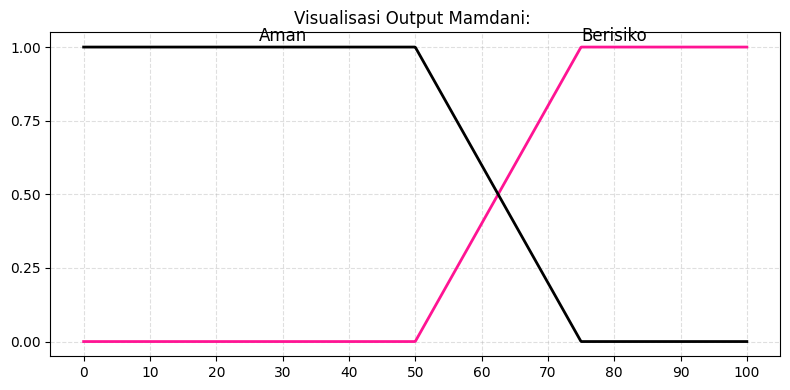

In [14]:
# Rentang nilai output (misalnya skor risiko 0–100)
x = np.linspace(0, 100, 1000)

# Fungsi keanggotaan fuzzy output
def berisiko(x):
    return np.where(x <= 50, 0,
           np.where(x <= 75, (x - 50) / 25, 1))

def aman(x):
    return np.where(x <= 50, 1,
           np.where(x <= 75, (75 - x) / 25, 0))

# Plotting
plt.figure(figsize=(8, 4))

plt.plot(x, berisiko(x), color='deeppink', linewidth=2, label='Berisiko')
plt.plot(x, aman(x), color='black', linewidth=2, label='Aman')

plt.title("Visualisasi Output Mamdani: ")
plt.ylim(-0.05, 1.05)
plt.yticks(np.linspace(0, 1, 5))
plt.xticks(np.arange(0, 110, 10))
plt.grid(True, linestyle='--', alpha=0.4)

# Teks label di atas puncak kurva
plt.text(30, 1.02, 'Aman', ha='center', fontsize=12)
plt.text(80, 1.02, 'Berisiko', ha='center', fontsize=12)

plt.tight_layout()
plt.show()

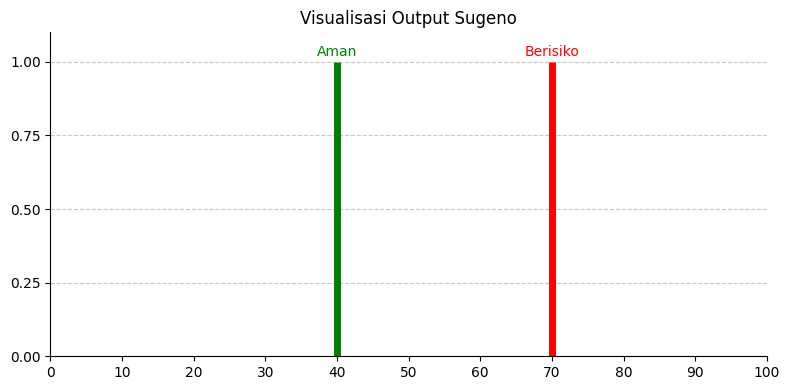

In [13]:
plt.figure(figsize=(8, 4))

# Garis vertikal dan label kategori
plt.vlines(x=40, ymin=0, ymax=1, colors='green', linewidth=5, label='Aman')
plt.vlines(x=70, ymin=0, ymax=1, colors='red', linewidth=5, label='Berisiko')

# Label di atas garis
plt.text(40, 1.02, 'Aman', ha='center', fontsize=10, color='green')
plt.text(70, 1.02, 'Berisiko', ha='center', fontsize=10, color='red')

# Atur sumbu
plt.ylim(0, 1.1)
plt.xlim(0, 100)
plt.xticks(range(0, 101, 10))
plt.yticks(np.linspace(0, 1, 5))

# Hilangkan frame atas dan kanan
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.title("Visualisasi Output Sugeno")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


### D. Visualisasi Perbandingan Mamdani & Sugeno
Pada tahap ini, kami mengambil dua sampel pasien untuk menguji performa sistem fuzzy Mamdani dan Sugeno. Hasil akhir ditampilkan dalam bentuk persentase dan diinterpretasikan ke dalam tiga kategori risiko, yaitu Aman, Waspada, dan Berisiko Tinggi, lengkap dengan visualisasi posisi output masing-masing metode pada grafik keanggotaan.

#### Pengujian Sampel Pasien 

In [15]:
#### Data input
usia_input = int(input("Masukkan usia :"))
glukosa_input = int(input("Masukkan kadar glukosa :"))

# Hitung hasil fuzzy
hasil_mamdani = fuzzy_diabetes_mamdani(usia_input, glukosa_input)
hasil_sugeno = fuzzy_diabetes_sugeno_linear(usia_input, glukosa_input)
status_mamdani = interpretasi_nilai(hasil_mamdani)
status_sugeno = interpretasi_nilai(hasil_sugeno)

print(f"[Mamdani] Hasil  : {hasil_mamdani:.2f}")
print(f"[Mamdani] Status : {status_mamdani}")
print(f"[Sugeno ] Hasil  : {hasil_sugeno:.2f}")
print(f"[Sugeno ] Status : {status_sugeno}")

Masukkan usia : 63
Masukkan kadar glukosa : 101


[Mamdani] Hasil  : 75.00
[Mamdani] Status : Berisiko
[Sugeno ] Hasil  : 65.00
[Sugeno ] Status : Berisiko


### F. Evaluasi Kinerja Mamdani & Sugeno
Untuk mengevaluasi kinerja metode Mamdani dan Sugeno, dilakukan pengujian terhadap dataset. Setiap sampel diuji untuk menghasilkan prediksi, kemudian dibandingkan dengan label sebenarnya menggunakan metrik akurasi, presisi, recall, dan F1-score.

In [19]:
data['Outcome_Label'] = ['Aman' if x == 0 else 'Berisiko' for x in data['Outcome']]
data[['Outcome', 'Outcome_Label']] # Kolom asli + kolom baru

,Outcome,Outcome_Label
0,1,Berisiko
1,0,Aman
2,1,Berisiko
3,0,Aman
4,1,Berisiko
...,...,...
758,0,Aman
759,0,Aman
760,0,Aman
761,1,Berisiko


In [17]:
# Fungsi interpretasi kualitas F1-Score
def interpret_f1_kategori(f1):
    if f1 < 50:
        return "Rendah"
    else:
        return "Tinggi"

# Fungsi untuk mengklasifikasikan hasil defuzzifikasi
def klasifikasi_risiko(n):
    return "Aman" if n < 50 else "Berisiko"

# Daftar untuk label sebenarnya dan prediksi
label_asli = []
prediksi_mamdani = []
prediksi_sugeno = []

# Iterasi untuk setiap baris data
for _, row in data.iterrows():
    usia = row['Age']
    glukosa = row['Glucose']
    label = row['Outcome_Label']  # kolom ini harus berisi "Aman" atau "Berisiko"

    label_asli.append(label)

    # Mamdani
    hasil_mamdani = fuzzy_diabetes_mamdani(usia, glukosa)
    pred_mam = klasifikasi_risiko(hasil_mamdani)
    prediksi_mamdani.append(pred_mam)

    # Sugeno
    hasil_sugeno = fuzzy_diabetes_sugeno_linear(usia, glukosa)
    pred_sug = klasifikasi_risiko(hasil_sugeno)
    prediksi_sugeno.append(pred_sug)

# Evaluasi Mamdani
akurasi_mamdani = accuracy_score(label_asli, prediksi_mamdani)
f1_mamdani = f1_score(label_asli, prediksi_mamdani, average='macro')

# Evaluasi Sugeno
akurasi_sugeno = accuracy_score(label_asli, prediksi_sugeno)
f1_sugeno = f1_score(label_asli, prediksi_sugeno, average='macro')

# Cetak hasil evaluasi
print("\n=== Evaluasi Fuzzy Mamdani ===")
print(f"Akurasi    : {akurasi_mamdani:.2f}")
print(f"F1-Score   : {f1_mamdani:.2f} ({interpret_f1_kategori(f1_mamdani)})")

print("\n=== Evaluasi Fuzzy Sugeno ===")
print(f"Akurasi    : {akurasi_sugeno:.2f}")
print(f"F1-Score   : {f1_sugeno:.2f} ({interpret_f1_kategori(f1_sugeno)})")

# Matriks kebingungan dan laporan klasifikasi
kelas = ['Aman', 'Berisiko']

print("\n=== Confusion Matrix Mamdani ===")
print(confusion_matrix(label_asli, prediksi_mamdani, labels=kelas))

print("\n=== Classification Report Mamdani ===")
print(classification_report(label_asli, prediksi_mamdani, labels=kelas))

print("\n=== Confusion Matrix Sugeno ===")
print(confusion_matrix(label_asli, prediksi_sugeno, labels=kelas))

print("\n=== Classification Report Sugeno ===")
print(classification_report(label_asli, prediksi_sugeno, labels=kelas))



=== Evaluasi Fuzzy Mamdani ===
Akurasi    : 0.72
F1-Score   : 0.71 (Rendah)

=== Evaluasi Fuzzy Sugeno ===
Akurasi    : 0.73
F1-Score   : 0.71 (Rendah)

=== Confusion Matrix Mamdani ===
[[357 140]
 [ 70 196]]

=== Classification Report Mamdani ===
              precision    recall  f1-score   support

        Aman       0.84      0.72      0.77       497
    Berisiko       0.58      0.74      0.65       266

    accuracy                           0.72       763
   macro avg       0.71      0.73      0.71       763
weighted avg       0.75      0.72      0.73       763


=== Confusion Matrix Sugeno ===
[[358 139]
 [ 70 196]]

=== Classification Report Sugeno ===
              precision    recall  f1-score   support

        Aman       0.84      0.72      0.77       497
    Berisiko       0.59      0.74      0.65       266

    accuracy                           0.73       763
   macro avg       0.71      0.73      0.71       763
weighted avg       0.75      0.73      0.73       763



In [18]:
# Data dummy
datah = pd.DataFrame({
    'Usia': [63, 27, 30, 47, 23],
    'Glukosa': [101, 122, 121, 126, 93],
    'Status': ['Aman', 'Aman', 'Aman', 'Berisiko', 'Aman']
})

# Proses data
results = []
for i in range(len(datah)):
    usia = datah.loc[i, 'Usia']
    glukosa = datah.loc[i, 'Glukosa']
    
    mam_score = fuzzy_diabetes_mamdani(usia, glukosa)
    sug_score = fuzzy_diabetes_sugeno_linear(usia, glukosa)
    
    results.append({
        'Usia': usia,
        'Glukosa': glukosa,
        'True_Label': datah.loc[i, 'Status'],
        'Mamdani_Prediction': mam_score,
        'Mamdani_Label': interpretasi_nilai(mam_score),
        'Sugeno_Prediction': sug_score,
        'Sugeno_Label': interpretasi_nilai(sug_score)
    })

# Hasil akhir
result_df = pd.DataFrame(results)
result_df

,Usia,Glukosa,True_Label,Mamdani_Prediction,Mamdani_Label,Sugeno_Prediction,Sugeno_Label
0,63,101,Aman,75.0,Berisiko,65.000000,Berisiko
1,27,122,Aman,25.0,Aman,45.000000,Aman
2,30,121,Aman,25.0,Aman,45.000000,Aman
3,47,126,Berisiko,75.0,Berisiko,55.000000,Berisiko
4,23,93,Aman,25.0,Aman,29.444445,Aman
